# OBloom Satellite capture Feature Extraction & Forecasting Pipeline

**End-to-end workflow:**

`Multispectral + Thermal Band Load (B02–B06 reflectance, B10 & B11 thermal)` → 
`Index & Derived Feature Computation (NDYI, ND_NIR_SWIR, NDVI, FII, micro‑anomalies)` → 
`Temporal Deltas (≤30 day lag) + Seasonal (DOY, sin, cos)` → 
`Blocky Spatial Aggregation (non‑overlapping window means)` → 
`Superbloom Label Integration` → 
`RandomForestRegressor Models (1) days until next superbloom  (2) next-scene FII map` → 
`Prediction, Evaluation (MAE/RMSE, error map)` → 
`Export (GeoTIFF + transparent PNG)`

---
## 1. Data & Band Loading
- Expects HLS Sentinel-2 style granule folders containing bands: **B02, B03, B04, B05, B06, B10, B11**.
- Extracts raster profile + sensing time metadata (`SENSING_TIME`).
- All reflectance bands scaled by a factor (default 0.0001). Thermal bands are float-prepared (nodata → NaN).
- Masking: Cloud / shadow masking (Fmask) purposefully omitted for simplicity—only finite values define validity.

## 2. Spectral Indices & Core Derivations
Computed per pixel:
- **NDYI** = (Green − Blue) / (Green + Blue)
- **ND_NIR_SWIR** = (NIR − SWIR1) / (NIR + SWIR1)
- **NDVI** = (NIR − Red) / (NIR + Red)
- **FII (Flower Intensity Index)**: `NDYI * clamp((NIR/SWIR1 − 1), 0, 5)` — simple bloom-intensity heuristic.
- Each index clipped to [−1, 1] where applicable; invalid pixels → NaN.
- Micro-anomaly layers: raw − local 3×3 mean (used for possible future refinements—currently stored but not modeled directly).
- Thermal stats for B10 & B11 also computed (mean/min/max/std + micro anomaly).

## 3. Temporal & Seasonal Context
- Per-scene scalar stats feed a delta engine: if previous scene within **30 days**, compute deltas for means of primary indices & thermal bands.
- Seasonal encoding of **Day Of Year (DOY)**: raw DOY plus **sin / cos** cyclical features.

## 4. Blocky Spatial Aggregation
- Non-overlapping window (parameter `window_px`) forms “blocky” generalized representations.
- For each index (and thermal bands if present) compute block means rebroadcast to full pixel grid (plus a block-level fraction of FII-positive pixels).
- Purpose: reduce noise, shrink training sample dimensionality, enable scalable modeling.

## 5. Superbloom Label Integration
- Input list accepts either `scene_dir` or `(scene_dir, label)` where `label` marks known superbloom period.
- Label stored as `know_superbloom_period` in both `stats_df` and `features_df` enabling supervised temporal forecasting.

## 6. Batch Processing Artifacts
Produces:
- `stats_df`: Per-scene structured summary (counts, thresholds, temporal deltas, seasonal, label).
- `features_df`: Enriched flat feature table merging scene stats + index/thermal summary metrics.
- `results_map`: Rich per-scene object with full-resolution arrays, blocky arrays, masks, seasonal & delta context.
- Auto-thresholding (`fii_threshold='auto'`) selects a cutoff to target a small positive fraction (default target ≈0.1%).

## 7. Modeling Stage
Two RandomForestRegressor tasks:
1. **Scene-level timing model**: Predicts `days_until_bloom` (regression) using scene-level numeric features (optional if enough labeled scenes exist).
2. **FII Map Forecast**: Learns transition `FII_t → FII_{t+1}` using consecutive scene pairs.
   - Modes:
     - Blocky mode (default): features = blocky NDVI, NDYI, ND_NIR_SWIR, FII, FII_positive_blocky_fraction (+ thermal if configured).
     - Pixel mode (optional future): per-pixel features (heavier memory footprint).
   - Training excludes final pair; final pair reserved for demonstration/test.
   - NaN handling: training samples with NaN target or feature values are removed; test metrics computed only on finite samples.

## 8. Evaluation & Diagnostics
- Reports **MAE** and **RMSE** for the FII map forecast on the held-out pair.
- Produces side-by-side visualization: Actual FII, Predicted FII, Error (Pred − Actual).
- Error distribution histogram for additional diagnostic insight.

## 9. Export
- Predicted and actual FII maps exported as single-band float32 **GeoTIFF** with `nodata` + mask → transparency (lossless LZW by default).
- Optional transparent **PNG** quick-look previews (NaNs → alpha=0).

## 10. Design Choices & Rationale
- Simplicity > exhaustive atmospheric correction—focus on clear scenes to minimize pre-processing complexity.
- Blocky aggregation chosen to reduce variance and training data volume while preserving spatial pattern structure.
- Random Forests selected for robustness with mixed-scale, non-normal feature distributions and low hyperparameter tuning overhead.
- Temporal delta window (30 days) balances capturing short phenological changes without introducing stale context.

## 11. Key Parameters to Tune
| Parameter | Purpose | Typical Adjustments |
|-----------|---------|---------------------|
| `window_px` | Controls spatial coarsening | 3–9 depending on noise & scale |
| `fii_threshold` / `auto_target_fraction` | Controls FII positive rarity | Adjust target fraction for sparser / denser detections |
| `sample_max` | Caps training sample count | Increase if memory allows for more fidelity |
| `n_estimators`, `min_samples_leaf`, `max_features` | RF capacity / generalization | Grid/Random search for performance |
| `MAX_DELTA_DAYS` | Temporal delta horizon | Longer for slower ecosystems |

## 12. Potential Enhancements (Future Work)
- Multi-scale blocky features (e.g., window_px ∈ {3, 7, 11}).
- Lag stacking (t−2, t−1 → t+1) for richer temporal memory.
- Gradient boosting / temporal CNN / transformer for sequence modeling.
- Cloud-Optimized GeoTIFF (COG) export & STAC metadata.
- Additional indices (e.g., red-edge vegetation indices, SWIR moisture indices).
- Cross-validation with time-aware folds (rolling origin).
- Explicit uncertainty estimation (quantile regression forests / ensemble spread).

## 13. Quick Reference (Core Objects)
- `summary_df` / `stats_df`: Scene-level numeric & categorical metadata.
- `features_df`: Modeling-ready flattened features.
- `results_map[scene_dir]`: Full structured per-scene dictionary (indices, blocky, masks, deltas, seasonals).
- `fii_map_forecast`: Dict containing fitted RF model, predicted map, actual map, metrics.

## 14. Workflow Snapshot
```
Scenes (Bands B02–B06, B10, B11)
  ↓ load_scene_bands
Indices (NDYI, ND_NIR_SWIR, NDVI, FII) + thermal stats
  ↓ temporal deltas + seasonal DOY
Blocky aggregation (window_px)
  ↓ label integration (superbloom periods)
Batch outputs (results_map, stats_df, features_df)
  ↓ RF training (timing model & FII map transition)
Prediction (next-scene FII map) + metrics
  ↓ GeoTIFF & PNG export
```

---
**Use:** Run cells top-to-bottom: load & process scenes → inspect visualization → run modeling cell → export results.

---

## Environment & Dependency Installation

This notebook relies on a lightweight geospatial + scientific Python stack. Below are the core libraries and optional add‑ons, with recommended install order and version pinning guidance (especially helpful on Windows).

### Core Packages
| Package | Purpose | Notes |
|---------|---------|-------|
| numpy | Array math backbone | Pin if reproducibility is critical |
| pandas | Tabular feature aggregation | 2.x compatible |
| rasterio | Read/write GeoTIFF & raster metadata | Wraps GDAL; compiled wheels recommended |
| scikit-image | Utility (e.g. block/patch operations) | Imported as `skimage` |
| scipy | Numerical filters (uniform_filter) | Required for micro-anomaly calc |
| scikit-learn | RandomForest models | Provides regressors & preprocessing |
| matplotlib | Visualization & PNG export | Any recent stable version |

### Optional / Future Extensions
| Package | Why You Might Add It |
|---------|----------------------|
| pyproj | CRS transformations if reprojecting / mosaicking |
| shapely | Vector masking / spatial joins |
| rasterstats | Zonal statistics over polygons |
| xarray / rioxarray | Multi-scene stacking & lazy IO |
| lightgbm / xgboost | Alternate gradient boosting models |

### Version Pinning (Example)
For full reproducibility you can pin (adjust versions to your policy):
```
numpy==1.26.4
pandas==2.2.2
rasterio==1.3.9
scikit-image==0.23.2
scipy==1.13.1
scikit-learn==1.5.2
matplotlib==3.9.2
```
If pinning, install in a **fresh virtual environment** to avoid dependency conflicts.

### Windows / GDAL Notes
- `rasterio` wheels bundle GDAL; avoid installing system GDAL separately unless necessary.
- If you encounter DLL load errors, try upgrading pip first (`python -m pip install --upgrade pip`) and reinstall rasterio.

### Basic Quick Install
Use the code cell below (kept separate so you can re-run if kernel resets). Add `--upgrade` if you need latest versions.

### Reproducible Install with Pins
Uncomment the pinned section in the code cell if you prefer strict versions.

---
The cell below will:
1. Upgrade pip (optional but recommended).
2. Install core dependencies quietly.
3. Print versions to verify the environment.

> Tip: If working offline or behind a firewall, pre-download wheels and point pip at a local directory with `--no-index --find-links=./wheels`.


In [ ]:
# Cell: Dependency Installation (run once per environment)
# You can re-run safely; add/remove packages as needed.
# If you prefer pinned versions, uncomment the pinned list.

upgrade_pip = True  # set False to skip pip upgrade
use_pins = False    # set True to install pinned versions shown below

base_packages = [
    'numpy',
    'pandas',
    'rasterio',
    'scikit-image',
    'scipy',
    'scikit-learn',
    'matplotlib'
]

pinned_packages = [
    'numpy==1.26.4',
    'pandas==2.2.2',
    'rasterio==1.3.9',
    'scikit-image==0.23.2',
    'scipy==1.13.1',
    'scikit-learn==1.5.2',
    'matplotlib==3.9.2'
]

install_list = pinned_packages if use_pins else base_packages

import subprocess, sys

def run(cmd):
    print('> ' + ' '.join(cmd))
    subprocess.check_call(cmd)

try:
    if upgrade_pip:
        run([sys.executable, '-m', 'pip', 'install', '--upgrade', 'pip'])
    run([sys.executable, '-m', 'pip', 'install', '--quiet', *install_list])
except subprocess.CalledProcessError as e:
    print('Installation error:', e)

# Version check
import importlib
print('\nPackage versions:')
for pkg in ['numpy','pandas','rasterio','skimage','scipy','sklearn','matplotlib']:
    try:
        m = importlib.import_module(pkg if pkg != 'skimage' else 'skimage')
        ver = getattr(m, '__version__', 'unknown')
        print(f'  {pkg:10s} {ver}')
    except Exception as exc:
        print(f'  {pkg:10s} (import failed: {exc})')

print('\nInstall cell complete. Set use_pins=True and re-run for reproducible environment.')

In [1]:
import numpy as np
import rasterio
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional, Union
import pandas as pd
import os, glob
from skimage.util import view_as_blocks
from scipy.ndimage import uniform_filter
from datetime import datetime, timezone
import math

In [2]:
# Cell: IO, Band Loading

BAND_SUFFIXES = {
    'B02': ['B02.tif', '.B02.tif'],
    'B03': ['B03.tif', '.B03.tif'],
    'B04': ['B04.tif', '.B04.tif'],
    'B05': ['B05.tif', '.B05.tif'],
    'B06': ['B06.tif', '.B06.tif'],
    'B10': ['B10.tif', '.B10.tif'],
    'B11': ['B11.tif', '.B11.tif'],
}

TIME_TAG_KEY = 'SENSING_TIME'
TIME_FORMAT = '%Y-%m-%dT%H:%M:%S.%fZ'

def _find_first_match(folder: str, patterns: List[str]) -> Optional[str]:
    for pattern in patterns:
        cand = glob.glob(os.path.join(folder, f"*{pattern}"))
        if cand:
            return cand[0]
    return None

def _parse_sensing_time(tags: Dict[str, str]) -> Optional[datetime]:
    t = tags.get(TIME_TAG_KEY)
    if not t:
        return None
    try:
        # Some tags might omit microseconds; try fallback
        try:
            return datetime.strptime(t, TIME_FORMAT).replace(tzinfo=timezone.utc)
        except ValueError:
            return datetime.fromisoformat(t.replace('Z','+00:00'))
    except Exception:
        return None

def load_scene_bands(scene_dir: str, require_all=True) -> Dict[str, np.ndarray]:
    """Load required spectral bands (B02..B06, B10, B11) plus profile and sensing time."""
    paths = {}
    for k, suffixes in BAND_SUFFIXES.items():
        p = _find_first_match(scene_dir, suffixes)
        if p:
            paths[k] = p
        else:
            if require_all:
                raise FileNotFoundError(f"Missing {k} in {scene_dir}")
            else:
                paths[k] = None
    with rasterio.open(paths['B02']) as s2:
        b2 = s2.read(1)
        profile = s2.profile
        t0 = _parse_sensing_time(s2.tags())
    with rasterio.open(paths['B03']) as s3:
        b3 = s3.read(1)
    with rasterio.open(paths['B04']) as s4:
        b4 = s4.read(1)
    with rasterio.open(paths['B05']) as s5:
        b5 = s5.read(1)
    with rasterio.open(paths['B06']) as s6:
        b6 = s6.read(1)
    with rasterio.open(paths['B10']) as s10:
        b10 = s10.read(1)
    with rasterio.open(paths['B11']) as s11:
        b11 = s11.read(1)
    shapes = {arr.shape for arr in [b2,b3,b4,b5,b6,b10,b11]}
    if len(shapes) != 1:
        raise ValueError(f"Shape mismatch in {scene_dir}")
    return dict(B02=b2,B03=b3,B04=b4,B05=b5,B06=b6,B10=b10,B11=b11,profile=profile,sensing_time=t0)

In [3]:
# Cell: Initial feature extraction, indices calculations

# Bright soils and dry or senescent vegetation can show spectral signatures similar to
# yellow petals in some Landsat bands, leading to false positives in bloom detection.
# To mitigate this effect, we applied a simple SWIR-based soil suppression step
# that down-weights pixels with strong SWIR reflectance.
# This approach is a lightweight substitute for more sophisticated spectral
# unmixing methods (e.g., spectral mixture analysis with the USGS Spectral Library v7),
# chosen due to time and computational constraints.

# In theory, feature extraction could be improved continuously using more advanced methods
# like spectral mixture analysis together with NASA's cloud-correction, interpolation and other tools (LaSRC + Sen2Cor harmonization, mosaicking, reprojection). 
# Fmask can further refine indices by masking clouds and shadows, but relying only on Fmask often
# produces very patchy data on mostly cloudy days, especially after other processing and training/prediction steps.
# For this hackathon, we instead focus on granules from mostly clear days (filterable at
# download via NASA EarthData), effectively skipping per-band Fmask masking before computing
# indices. This simplifies the workflow while still producing meaningful bloom signals.

# ---- Temporal context helpers ----
MAX_DELTA_DAYS = 30

def _compute_temporal_deltas(current_stats: Dict[str, float], prev_stats: Optional[Dict[str, float]],
                             current_time: Optional[datetime], prev_time: Optional[datetime]) -> Dict[str, Optional[float]]:
    """Compute temporal deltas (current - previous) for selected scalar stats if within MAX_DELTA_DAYS.
    If no previous or outside window, returns None for each delta.
    """
    keys = ['NDYI_mean','ND_NIR_SWIR_mean','NDVI_mean','FII_mean','TIR_B10_mean','TIR_B11_mean']
    out = {f'delta_{k}': None for k in keys}
    if prev_stats is None or current_time is None or prev_time is None:
        return out
    dt_days = (current_time - prev_time).days
    if dt_days < 0 or dt_days > MAX_DELTA_DAYS:
        return out
    for k in keys:
        if k in current_stats and k in prev_stats:
            c = current_stats[k]
            p = prev_stats[k]
            out[f'delta_{k}'] = (c - p) if (c is not None and p is not None) else None
    out['delta_days'] = dt_days
    return out

def _seasonal_features(t: Optional[datetime]) -> Dict[str, Optional[float]]:
    if t is None:
        return {'doy_sin': None, 'doy_cos': None, 'doy': None}
    # Day of year (1..366)
    doy = t.timetuple().tm_yday
    angle = 2 * math.pi * (doy / 365.0)
    return {'doy_sin': math.sin(angle), 'doy_cos': math.cos(angle), 'doy': doy}

def _prep_reflectance(
    arr: np.ndarray, scale_factor=0.0001, nodata_value=-9999
) -> np.ndarray:
    arr = arr.astype("float32")
    nodata_mask = arr <= (nodata_value + 1)
    arr[nodata_mask] = np.nan
    if scale_factor and scale_factor != 1.0:
        arr *= scale_factor
    return arr


def _safe_nd(a: np.ndarray, b: np.ndarray, eps=1e-6) -> np.ndarray:
    denom = a + b
    with np.errstate(divide="ignore", invalid="ignore"):
        nd = (a - b) / (denom + eps)
    return nd

def prep_thermal(arr: np.ndarray, nodata_value=-9999) -> np.ndarray:
    """Prepare thermal band array: cast to float32, replace nodata with np.nan."""
    arr = arr.astype("float32")
    nodata_mask = arr <= (nodata_value + 1)
    arr[nodata_mask] = np.nan
    return arr


def compute_indices(
    b2: np.ndarray,
    b3: np.ndarray,
    b4: np.ndarray,
    b5: np.ndarray,
    b6: np.ndarray,
    b10: np.ndarray,
    b11: np.ndarray,
    scale_factor=0.0001,
    nodata_value=-9999,
    eps=1e-6
):
    b2f = _prep_reflectance(b2, scale_factor, nodata_value)
    b3f = _prep_reflectance(b3, scale_factor, nodata_value)
    b4f = _prep_reflectance(b4, scale_factor, nodata_value)
    b5f = _prep_reflectance(b5, scale_factor, nodata_value)
    b6f = _prep_reflectance(b6, scale_factor, nodata_value)
    b10t = prep_thermal(b10)
    b11t = prep_thermal(b11)

    # Valid now simply means all bands are finite
    valid = (
        ~np.isnan(b2f)
        & ~np.isnan(b3f)
        & ~np.isnan(b4f)
        & ~np.isnan(b5f)
        & ~np.isnan(b6f)
    )

    NDYI = _safe_nd(b3f, b2f, eps)
    ND_NIR_SWIR = _safe_nd(b5f, b6f, eps)
    NDVI = _safe_nd(b5f, b4f, eps)

    NDYI = np.clip(NDYI, -1, 1)
    ND_NIR_SWIR = np.clip(ND_NIR_SWIR, -1, 1)
    NDVI = np.clip(NDVI, -1, 1)

    with np.errstate(divide="ignore", invalid="ignore"):
        nir_swir_ratio = b5f / (b6f + eps)
        
    # Rudimentary implementation of a Flower Intensity Index with capped ratio contribution
    FII = NDYI * np.minimum(np.maximum(nir_swir_ratio - 1.0, 0), 5.0)

    # Apply NaN mask
    for arr in (NDYI, ND_NIR_SWIR, NDVI, FII):
        arr[~valid] = np.nan

    # Helper to compute per-tile statistics
    def stats(arr):
        return {
            "mean": float(np.nanmean(arr)) if np.isfinite(np.nanmean(arr)) else None,
            "max": float(np.nanmax(arr)) if np.isfinite(np.nanmax(arr)) else None,
            "min": float(np.nanmin(arr)) if np.isfinite(np.nanmin(arr)) else None,
            "std": float(np.nanstd(arr)) if np.isfinite(np.nanstd(arr)) else None,
        }

    # Helper to compute micro-anomaly (central - local 3x3 mean)
    def micro_anomaly(arr):
        local_mean = uniform_filter(np.nan_to_num(arr, nan=0.0), size=3, mode='nearest')
        return arr - local_mean

    # Compute statistics for indices
    index_stats = {}
    for name, arr in zip(["NDYI", "ND_NIR_SWIR", "NDVI", "FII"], [NDYI, ND_NIR_SWIR, NDVI, FII]):
        st = stats(arr)
        for k,v in st.items():
            index_stats[f"{name}_{k}"] = v
        index_stats[name + "_micro_anomaly"] = micro_anomaly(arr)

    # Thermal stats (per-band)
    TIR_stats = {}
    for name, arr in zip(["TIR_B10", "TIR_B11"], [b10t, b11t]):
        st = stats(arr)
        for k,v in st.items():
            TIR_stats[f"{name}_{k}"] = v
        TIR_stats[name + "_micro_anomaly"] = micro_anomaly(arr)

    return {
        "indices": {
            "NDYI": NDYI,
            "ND_NIR_SWIR": ND_NIR_SWIR,
            "NDVI": NDVI,
            "FII": FII,
            "valid_mask": valid,
        },
        "index_stats": index_stats,
        "TIR_stats": TIR_stats,
    }

In [4]:
# --------------- Sliding Window (Blocky) Aggregation & Processing ---------------

from math import isfinite as _isfinite_builtin
from typing import Union, Tuple, List
import warnings

# Type alias for the user-supplied label designating whether a scene is within a known superbloom period
LabelType = Union[int, float, bool, str]

def blocky_average(arr: np.ndarray, window: int) -> np.ndarray:
    """Compute a blocky (non-overlapping) window-mean representation.
    Crops edges so shape is multiple of window, then broadcasts block means back
    to block size. NaNs are ignored in the mean; if an entire block is NaN,
    result block is NaN.
    """
    if window < 1:
        raise ValueError("window must be >=1")
    h, w = arr.shape
    hc = h - (h % window)
    wc = w - (w % window)
    core = arr[:hc, :wc]
    # reshape into (n_blocks_h, window, n_blocks_w, window)
    bh = hc // window
    bw = wc // window
    reshaped = core.reshape(bh, window, bw, window)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        means = np.nanmean(reshaped, axis=(1,3)) # shape (bh, bw)
    # Broadcast back
    blocky = np.repeat(np.repeat(means, window, axis=0), window, axis=1)
    # Pad back if needed
    if hc != h or wc != w:
        padded = np.full_like(arr, np.nan, dtype='float32')
        padded[:hc, :wc] = blocky
        blocky = padded
    return blocky.astype('float32')

@dataclass
class SceneStatsEnhanced:
    scene_dir: str
    scene_id: str
    sensing_time: Optional[datetime]
    n_valid: int
    n_fii_positive: int
    fii_ratio: float
    fii_threshold: float
    detection_mode: str
    threshold_mode: str
    doy: Optional[int]
    doy_sin: Optional[float]
    doy_cos: Optional[float]
    # New supervised/label feature: whether this scene is within a known superbloom period
    know_superbloom_period: Optional[LabelType] = None
    # Temporal deltas (may be None)
    delta_days: Optional[int] = None
    delta_NDYI_mean: Optional[float] = None
    delta_ND_NIR_SWIR_mean: Optional[float] = None
    delta_NDVI_mean: Optional[float] = None
    delta_FII_mean: Optional[float] = None
    delta_TIR_B10_mean: Optional[float] = None
    delta_TIR_B11_mean: Optional[float] = None
    window_px: int = 3


def _auto_threshold(detection_array: np.ndarray, valid_mask: np.ndarray, target_positive_fraction=0.001) -> float:
    vals = detection_array[(detection_array > 0) & valid_mask]
    if vals.size == 0:
        return 0.0
    pct = max(0, 100 * (1 - target_positive_fraction))
    pct = min(100, pct)
    thr = float(np.percentile(vals, pct))
    if thr == 0:
        thr = float(vals.max()) * 0.05
    return thr

def process_scene_enhanced(scene_dir: str,
                           fii_threshold: Union[float, str] = 0.02,
                           scale_factor: float = 0.0001,
                           nodata_value: int = -9999,
                           detection_mode: str = 'fii',
                           auto_target_fraction: float = 0.001,
                           prev_stats: Optional[Dict[str, float]] = None,
                           prev_time: Optional[datetime] = None,
                           window_px: int = 3,
                           know_superbloom_period: Optional[LabelType] = None) -> dict:
    data = load_scene_bands(scene_dir)
    sensing_time = data.get('sensing_time')

    idx = compute_indices(data['B02'], data['B03'], data['B04'], data['B05'], data['B06'], data['B10'], data['B11'],
                          scale_factor=scale_factor, nodata_value=nodata_value)

    # Build a flat current stats dict for delta comparison
    flat_current = {}
    flat_current.update(idx['index_stats'])
    flat_current.update(idx['TIR_stats'])

    # Seasonal features
    season = _seasonal_features(sensing_time)

    # Temporal deltas
    deltas = _compute_temporal_deltas(flat_current, prev_stats, sensing_time, prev_time)

    detection_array = idx['indices']['FII']  # only one detection mode for now
    valid_mask = idx['indices']['valid_mask']

    if isinstance(fii_threshold, str) and fii_threshold.lower() == 'auto':
        used_threshold = _auto_threshold(detection_array, valid_mask, target_positive_fraction=auto_target_fraction)
        threshold_mode = 'auto'
    else:
        used_threshold = float(fii_threshold)
        threshold_mode = 'fixed'

    n_valid = int(np.nansum(valid_mask))
    if n_valid == 0:
        scene_id = os.path.basename(os.path.normpath(scene_dir))
        stats = SceneStatsEnhanced(
            scene_dir=scene_dir,
            scene_id=scene_id,
            sensing_time=sensing_time,
            n_valid=0,
            n_fii_positive=0,
            fii_ratio=np.nan,
            fii_threshold=used_threshold,
            detection_mode=detection_mode,
            threshold_mode=threshold_mode,
            doy=season['doy'],
            doy_sin=season['doy_sin'],
            doy_cos=season['doy_cos'],
            know_superbloom_period=know_superbloom_period,
            window_px=window_px,
            **{k: deltas.get(k) for k in deltas}
        )
        return {
            'stats': stats,
            **idx,
            'fii_positive': np.zeros_like(valid_mask, dtype=bool),
            'bands_profile': data['profile'],
            'flat_stats': flat_current,
            'blocky_indices': {},
        }

    fii_positive = (detection_array >= used_threshold) & valid_mask
    n_fii_positive = int(np.nansum(fii_positive))
    fii_ratio = (n_fii_positive / n_valid) if n_valid else np.nan
    scene_id = os.path.basename(os.path.normpath(scene_dir))

    # Create blocky (non-overlapping) versions of indices & thermal arrays
    blocky = {}
    for name in ['NDVI','NDYI','ND_NIR_SWIR','FII']:
        blocky[name] = blocky_average(idx['indices'][name], window_px)
    # Thermal blocky
    thermal_arrays = idx.get('thermal_arrays', {})
    for tname, tarr in thermal_arrays.items():
        blocky[tname] = blocky_average(tarr, window_px)
    blocky['FII_positive_blocky_fraction'] = blocky_average(fii_positive.astype('float32'), window_px)

    stats = SceneStatsEnhanced(
        scene_dir=scene_dir,
        scene_id=scene_id,
        sensing_time=sensing_time,
        n_valid=n_valid,
        n_fii_positive=n_fii_positive,
        fii_ratio=fii_ratio,
        fii_threshold=used_threshold,
        detection_mode=detection_mode,
        threshold_mode=threshold_mode,
        doy=season['doy'],
        doy_sin=season['doy_sin'],
        doy_cos=season['doy_cos'],
        know_superbloom_period=know_superbloom_period,
        window_px=window_px,
        **{k: deltas.get(k) for k in deltas}
    )

    return {
        'stats': stats,
        **idx,
        'fii_positive': fii_positive,
        'bands_profile': data['profile'],
        'flat_stats': flat_current,
        'seasonal': season,
        'deltas': deltas,
        'blocky_indices': blocky,
    }

def batch_process_enhanced(scene_dirs: List[Union[str, Tuple[str, LabelType]]],
                           fii_threshold: Union[float, str] = 'auto',
                           scale_factor: float = 0.0001,
                           nodata_value: int = -9999,
                           detection_mode: str = 'fii',
                           auto_target_fraction: float = 0.001,
                           window_px: int = 3):
    """Process scenes sequentially (time-sorted) producing stats and blocky window features.

    scene_dirs can be either:
      * List[str]  (backwards compatible) OR
      * List[Tuple[str, LabelType]] where the second element is a user-provided
        label/flag indicating a known superbloom period ("know_superbloom_period").

    Returns:
      stats_df: DataFrame of SceneStatsEnhanced
      results: dict mapping scene_dir -> detailed result
      errors: dict of failures
      features_df: DataFrame joining stats + per-scene scalar index/thermal stats (includes know_superbloom_period)
    """
    results = {}
    errors = {}
    feature_rows = []

    # Time sort with label retention
    enriched = []  # (dir, ts, label)
    for item in scene_dirs:
        if isinstance(item, (list, tuple)) and len(item) == 2:
            d, label = item
        else:
            d, label = item, None
        try:
            probe = load_scene_bands(d, require_all=False)
            ts = probe.get('sensing_time')
        except Exception:
            ts = None
        enriched.append((d, ts, label))
    enriched.sort(key=lambda x: x[1] or datetime.max.replace(tzinfo=timezone.utc))

    prev_stats = None
    prev_time = None
    for d, _, label in enriched:
        try:
            res = process_scene_enhanced(d, fii_threshold, scale_factor, nodata_value,
                                         detection_mode, auto_target_fraction,
                                         prev_stats=prev_stats, prev_time=prev_time,
                                         window_px=window_px,
                                         know_superbloom_period=label)
            results[d] = res
            prev_stats = res.get('flat_stats')
            prev_time = res['stats'].sensing_time

            fs = {'scene_dir': res['stats'].scene_dir, 'scene_id': res['stats'].scene_id}
            st_dict = asdict(res['stats'])
            if st_dict.get('sensing_time'):
                st_dict['sensing_time'] = st_dict['sensing_time'].isoformat()
            fs.update(st_dict)
            flat_stats = res['flat_stats']
            for k,v in flat_stats.items():
                if k.endswith('_micro_anomaly'):
                    continue
                fs[k] = v
            feature_rows.append(fs)
        except Exception as e:
            errors[d] = str(e)

    stats_rows = [asdict(v['stats']) for v in results.values()]
    stats_df = pd.DataFrame(stats_rows).sort_values('sensing_time') if stats_rows else pd.DataFrame()
    features_df = pd.DataFrame(feature_rows).sort_values('sensing_time') if feature_rows else pd.DataFrame()
    return stats_df, results, errors, features_df

print("Processing module loaded (sliding window blocky features, superbloom label & thermal blocky support).")

Processing module loaded (sliding window blocky features, superbloom label & thermal blocky support).


In [ ]:
# Example: list your scene directories (each directory contains the B02..B06 + B10/B11 files)
# You can now optionally provide a (scene_dir, know_superbloom_period) tuple.
# The label can be bool/int/float/str. It will appear in stats_df & features_df.

scene_dirs = [
    # Example scenes; label True meaning within known superbloom period.
    (r"data\\HLS Sentinel-2 Multi-spectral Instrument Surface Reflectance Daily Global 30m v2.0\\Carizon Plain\\20190313", True),
    (r"data\\HLS Sentinel-2 Multi-spectral Instrument Surface Reflectance Daily Global 30m v2.0\\Carizon Plain\\20190318", True),
    (r"data\\HLS Sentinel-2 Multi-spectral Instrument Surface Reflectance Daily Global 30m v2.0\\Carizon Plain\\20190328", True),
    (r"data\\HLS Sentinel-2 Multi-spectral Instrument Surface Reflectance Daily Global 30m v2.0\\Carizon Plain\\20190407", True),
    (r"data\\HLS Sentinel-2 Multi-spectral Instrument Surface Reflectance Daily Global 30m v2.0\\Carizon Plain\\20190412", False),
    (r"data\\HLS Sentinel-2 Multi-spectral Instrument Surface Reflectance Daily Global 30m v2.0\\Carizon Plain\\20190417", False),
    (r"data\\HLS Sentinel-2 Multi-spectral Instrument Surface Reflectance Daily Global 30m v2.0\\Carizon Plain\\20190422", False),
    (r"data\\HLS Sentinel-2 Multi-spectral Instrument Surface Reflectance Daily Global 30m v2.0\\Carizon Plain\\20190206", False),
    (r"data\\HLS Sentinel-2 Multi-spectral Instrument Surface Reflectance Daily Global 30m v2.0\\Carizon Plain\\20190211", False),
    (r"data\\HLS Sentinel-2 Multi-spectral Instrument Surface Reflectance Daily Global 30m v2.0\\Carizon Plain\\20190216", False),
    # Additional scenes could be added like:
    # (r"<path_to_scene2>", False),
]

# Run batch with sliding-window block size (window_px)
summary_df, results_map, errors, features_df = batch_process_enhanced(
    scene_dirs,
    fii_threshold='auto',
    scale_factor=0.0001,
    nodata_value=-9999,
    detection_mode='fii',
    auto_target_fraction=0.001,
    window_px=5
)

print('Errors:', errors)
print('Summary columns (truncated):', summary_df.columns.tolist()[:25])
print('Features columns (truncated):', features_df.columns.tolist()[:35])
print('\nSuperbloom label column sample (know_superbloom_period):')
print(features_df[['scene_id','know_superbloom_period']].head())
summary_df.head()

Errors: {}
Summary columns (truncated): ['scene_dir', 'scene_id', 'sensing_time', 'n_valid', 'n_fii_positive', 'fii_ratio', 'fii_threshold', 'detection_mode', 'threshold_mode', 'doy', 'doy_sin', 'doy_cos', 'know_superbloom_period', 'delta_days', 'delta_NDYI_mean', 'delta_ND_NIR_SWIR_mean', 'delta_NDVI_mean', 'delta_FII_mean', 'delta_TIR_B10_mean', 'delta_TIR_B11_mean', 'window_px']
Features columns (truncated): ['scene_dir', 'scene_id', 'sensing_time', 'n_valid', 'n_fii_positive', 'fii_ratio', 'fii_threshold', 'detection_mode', 'threshold_mode', 'doy', 'doy_sin', 'doy_cos', 'know_superbloom_period', 'delta_days', 'delta_NDYI_mean', 'delta_ND_NIR_SWIR_mean', 'delta_NDVI_mean', 'delta_FII_mean', 'delta_TIR_B10_mean', 'delta_TIR_B11_mean', 'window_px', 'NDYI_mean', 'NDYI_max', 'NDYI_min', 'NDYI_std', 'ND_NIR_SWIR_mean', 'ND_NIR_SWIR_max', 'ND_NIR_SWIR_min', 'ND_NIR_SWIR_std', 'NDVI_mean', 'NDVI_max', 'NDVI_min', 'NDVI_std', 'FII_mean', 'FII_max']

Superbloom label column sample (know_supe

,scene_dir,scene_id,sensing_time,n_valid,n_fii_positive,fii_ratio,fii_threshold,detection_mode,threshold_mode,doy,...,doy_cos,know_superbloom_period,delta_days,delta_NDYI_mean,delta_ND_NIR_SWIR_mean,delta_NDVI_mean,delta_FII_mean,delta_TIR_B10_mean,delta_TIR_B11_mean,window_px
0,C:\\Users\\Littlebone\\source\\repos\\bloomwat...,20190206,2019-02-06 18:54:47.368000+00:00,13387356,493,0.000037,3.502721,fii,auto,37,...,0.803928,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
1,C:\\Users\\Littlebone\\source\\repos\\bloomwat...,20190211,2019-02-11 18:54:50.528000+00:00,13395196,382,0.000029,2.166196,fii,auto,42,...,0.749826,False,5.0,0.037631,0.027772,-0.111931,-0.010248,25.369057,29.831421,5
2,C:\\Users\\Littlebone\\source\\repos\\bloomwat...,20190216,2019-02-16 18:54:46.881000+00:00,13386972,632,0.000047,4.997173,fii,auto,47,...,0.690173,False,4.0,-0.054223,-0.031673,0.175664,0.021590,-25.159420,170.890137,5
3,C:\\Users\\Littlebone\\source\\repos\\bloomwat...,20190313,2019-03-13 18:54:47.694416+00:00,13395192,12768,0.000953,5.000000,fii,auto,72,...,0.325342,True,25.0,0.128439,-0.013927,-0.062115,0.032750,5.596724,25.860962,5
4,C:\\Users\\Littlebone\\source\\repos\\bloomwat...,20190318,2019-03-18 18:54:47.782537+00:00,13380620,393,0.000029,2.175774,fii,auto,77,...,0.242850,True,5.0,-0.065529,0.005812,-0.035169,-0.046281,-17.224927,280.551392,5


Scene: C:\\Users\\Littlebone\\source\\repos\\bloomwatch\\data\\HLS Sentinel-2 Multi-spectral Instrument Surface Reflectance Daily Global 30m v2.0\\Carizon Plain\\20190206


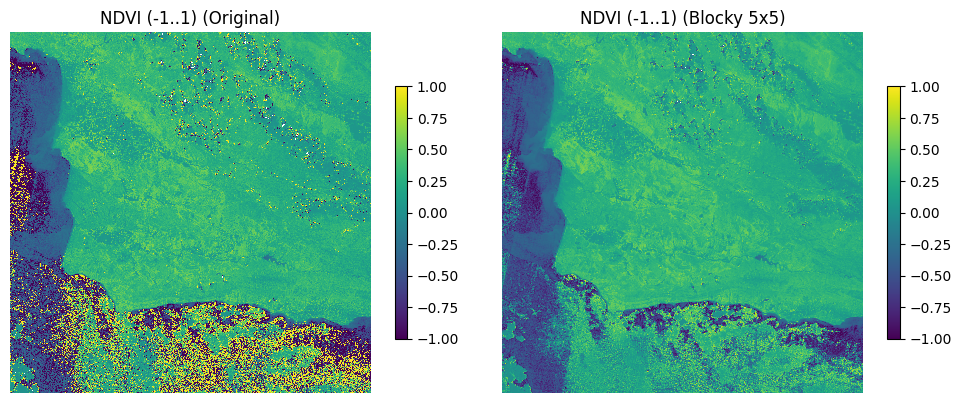

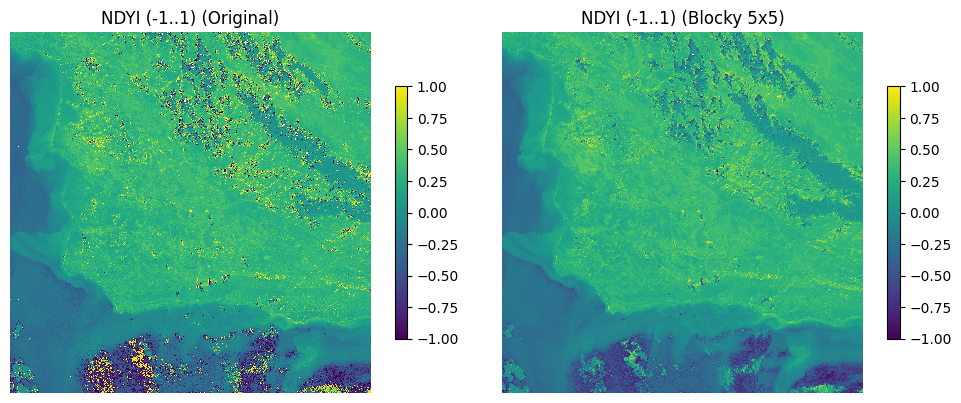

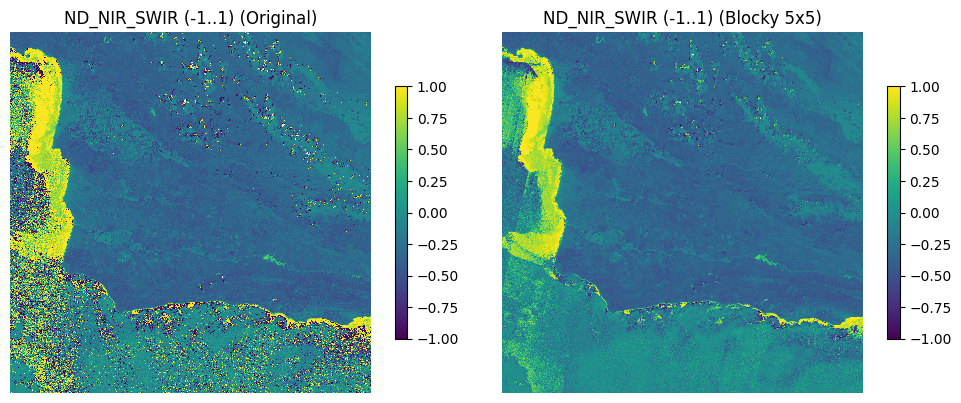

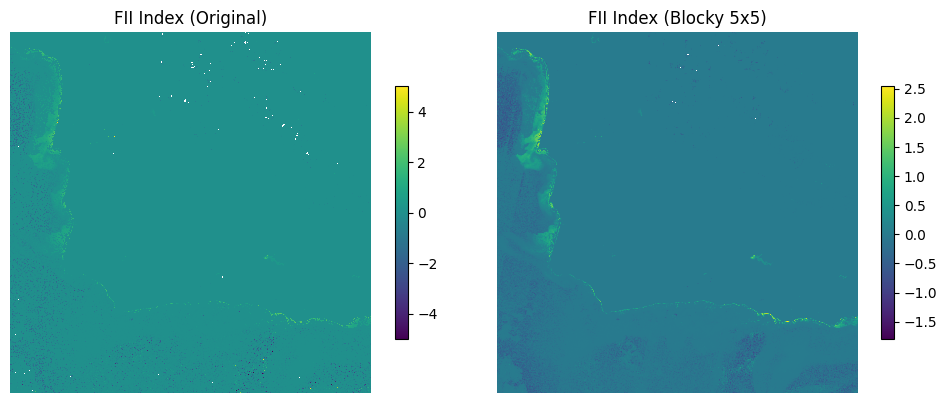

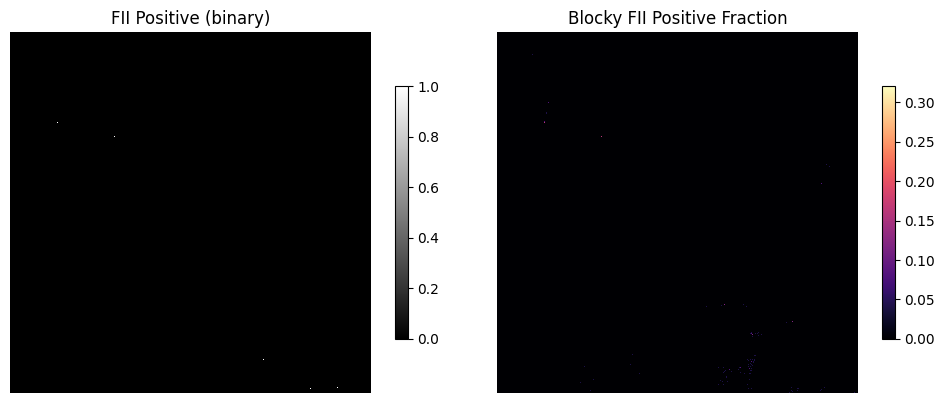

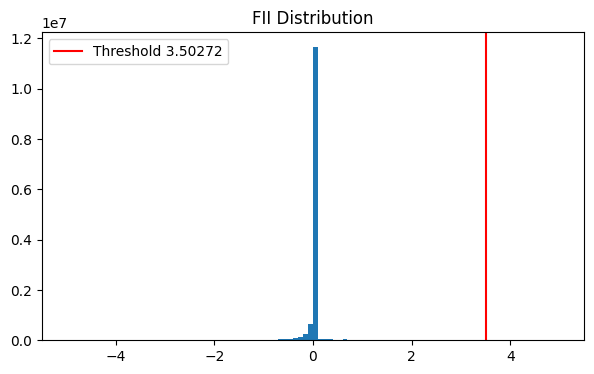

FII positives fraction: 3.682579293476621e-05
Temporal window px: 5
Seasonal DOY: 37 sin: 0.5947266869607633 cos: 0.8039279618328213


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Visual comparison of original vs blocky indices
if 'results_map' not in globals() or not results_map:
    raise RuntimeError('Run the batch processing cell first.')

scene_key, scene_data = next(iter(results_map.items()))
print('Scene:', scene_key)

indices = scene_data['indices']
blocky = scene_data['blocky_indices']
fii_positive = scene_data['fii_positive']

pairs = [
    ('NDVI', 'NDVI (-1..1)'),
    ('NDYI', 'NDYI (-1..1)'),
    ('ND_NIR_SWIR', 'ND_NIR_SWIR (-1..1)'),
    ('FII', 'FII Index'),
]

for name, title in pairs:
    orig = indices[name]
    blk = blocky[name]
    fig, axes = plt.subplots(1,2, figsize=(10,4))
    im0 = axes[0].imshow(orig, cmap='viridis', interpolation='nearest')
    axes[0].set_title(f'{title} (Original)')
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], shrink=0.7)
    im1 = axes[1].imshow(blk, cmap='viridis', interpolation='nearest')
    axes[1].set_title(f'{title} (Blocky {scene_data["stats"].window_px}x{scene_data["stats"].window_px})')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], shrink=0.7)
    plt.tight_layout()
    plt.show()

# FII positives vs blocky fraction
fig, axes = plt.subplots(1,2, figsize=(10,4))
im0 = axes[0].imshow(fii_positive.astype(float), cmap='gray', interpolation='nearest')
axes[0].set_title('FII Positive (binary)')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], shrink=0.7)
blk_frac = blocky['FII_positive_blocky_fraction']
im1 = axes[1].imshow(blk_frac, cmap='magma', interpolation='nearest')
axes[1].set_title('Blocky FII Positive Fraction')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], shrink=0.7)
plt.tight_layout()
plt.show()

# Histogram of FII with threshold
FII = indices['FII']
finite_fii = FII[np.isfinite(FII)]
if finite_fii.size:
    plt.figure(figsize=(7,4))
    plt.hist(finite_fii, bins=100)
    thr = scene_data['stats'].fii_threshold
    plt.axvline(thr, color='red', label=f'Threshold {thr:.5f}')
    plt.title('FII Distribution')
    plt.legend()
    plt.show()
    print('FII positives fraction:', fii_positive.sum() / indices['valid_mask'].sum())
else:
    print('No finite FII values.')

print('Temporal window px:', scene_data['stats'].window_px)
print('Seasonal DOY:', scene_data['stats'].doy, 'sin:', scene_data['stats'].doy_sin, 'cos:', scene_data['stats'].doy_cos)

Insufficient data for scene-level days-until-bloom model.
Removed 62 samples with NaN targets from training.
Removed 62 samples with NaN targets from training.
Removed 106 samples with NaN feature values.
Training samples: 200000  Features per sample: 5
Removed 106 samples with NaN feature values.
Training samples: 200000  Features per sample: 5
FII map forecast (blocky) test MAE=0.03114 RMSE=0.09043 samples=535824
FII map forecast (blocky) test MAE=0.03114 RMSE=0.09043 samples=535824


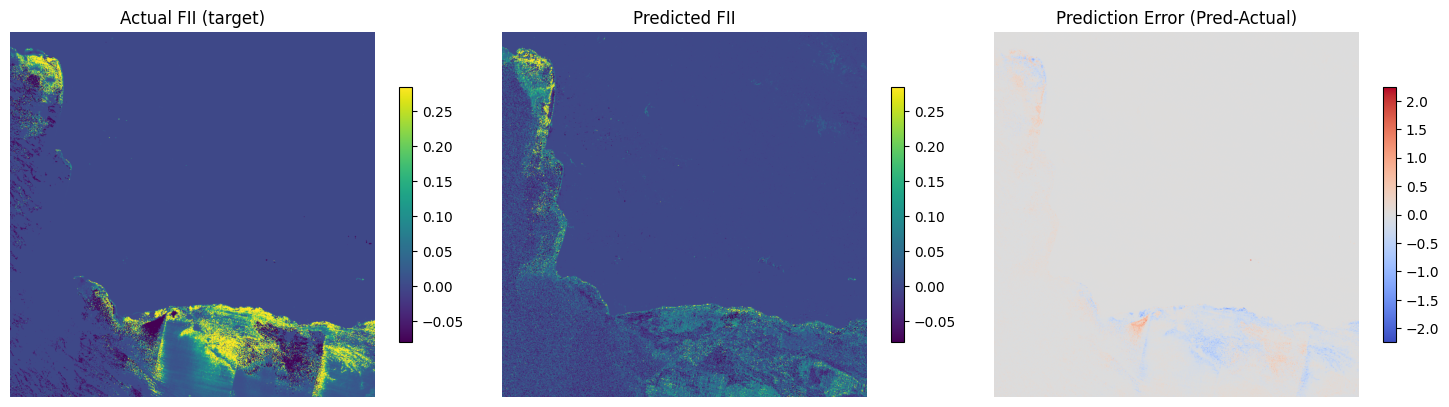

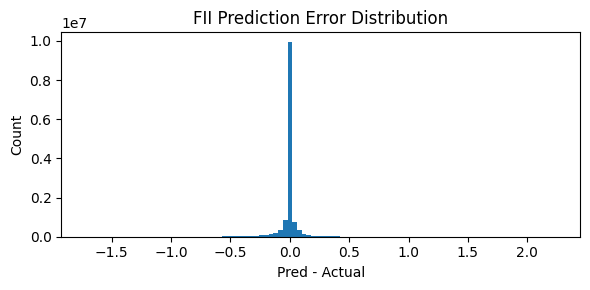

Stored fii_map_forecast dict with predicted_map & actual_map.


In [10]:
# Cell: Superbloom timing + FII map forecasting (replaces mean FII prediction)
# This cell now:
#   1) (Optional) Predicts days until next superbloom (scene-level regression)
#   2) Predicts the next-scene FII map (either blocky resolution or original resolution) using
#      a classical scikit-learn regression trained on consecutive scene pairs.
#
# FII Map Forecast Approach:
#   - Sort scenes chronologically.
#   - For each consecutive pair (t -> t+1), build training samples using the t scene as features
#     and the (t+1) scene's FII as target.
#   - Features (per spatial element):
#       If use_blocky = True (default): blocky means of NDVI, NDYI, ND_NIR_SWIR, FII, FII_positive_fraction,
#         plus optionally thermal blocky arrays if present.
#       If use_blocky = False: per-pixel NDVI, NDYI, ND_NIR_SWIR, previous FII, and FII positive mask (as float).
#     Scene-level seasonal features (doy, sin, cos) get broadcast when using per-pixel; for blocky we append them directly.
#   - Train RandomForestRegressor on all pairs except final pair; test on final pair for demonstration.
#   - Reconstruct and visualize predicted FII map vs actual.
#
# Notes / Caveats:
#   - With few scenes this model will be highly biased/overfit; it's a structural example.
#   - Random Forest is chosen for simplicity; you can swap for GradientBoostingRegressor or others.
#   - To incorporate temporal deltas more explicitly, you could build lag stacks (t-2 -> t) etc.
#   - For large rasters, consider downsampling or sampling a subset of blocks/pixels (sample_max).

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import math

if 'features_df' not in globals() or features_df.empty:
    raise RuntimeError('features_df is empty – run batch processing first.')
if 'results_map' not in globals() or not results_map:
    raise RuntimeError('results_map is empty – run batch processing first.')

# ------------------ (1) Superbloom timing model (scene-level) ------------------
# Retain earlier scene-level regression for days until next bloom (optional)
# You can disable by setting run_scene_level_model = False
run_scene_level_model = True

fdf = features_df.copy().sort_values('sensing_time').reset_index(drop=True)
fdf['sensing_dt'] = pd.to_datetime(fdf['sensing_time'])
fdf['superbloom_label'] = fdf['know_superbloom_period'].astype(bool)

# Target: days until next superbloom
next_bloom_days = []
for i in range(len(fdf)):
    current_time = fdf.loc[i, 'sensing_dt']
    sub = fdf.loc[(fdf.index > i) & (fdf['superbloom_label'])]
    if sub.empty:
        next_bloom_days.append(np.nan)
    else:
        next_time = sub.iloc[0]['sensing_dt']
        next_bloom_days.append((next_time - current_time).days)

fdf['target_days_until_bloom'] = next_bloom_days

if run_scene_level_model:
    exclude_cols = set(['scene_dir','scene_id','sensing_time','sensing_dt','know_superbloom_period','superbloom_label','target_days_until_bloom'])
    numeric_cols_scene = [c for c in fdf.columns if c not in exclude_cols and np.issubdtype(fdf[c].dtype, np.number)]
    split_idx = int(len(fdf) * 0.7) if len(fdf) > 3 else max(1, len(fdf)-1)
    train_df_scene = fdf.iloc[:split_idx].copy()
    test_df_scene = fdf.iloc[split_idx:].copy()
    tr = train_df_scene.dropna(subset=['target_days_until_bloom'])
    te = test_df_scene.dropna(subset=['target_days_until_bloom'])
    if not tr.empty and not te.empty:
        X_tr = tr[numeric_cols_scene]
        y_tr = tr['target_days_until_bloom']
        X_te = te[numeric_cols_scene]
        y_te = te['target_days_until_bloom']
        scene_pipeline = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('rf', RandomForestRegressor(n_estimators=200, random_state=42, min_samples_leaf=2))
        ])
        scene_pipeline.fit(X_tr, y_tr)
        preds = scene_pipeline.predict(X_te)
        mae = mean_absolute_error(y_te, preds)
        print(f"Scene-level days-until-bloom model: MAE={mae:.3f} days (test samples={len(preds)})")
    else:
        print('Insufficient data for scene-level days-until-bloom model.')

# ------------------ (2) FII Map Forecasting ------------------

# Configuration
use_blocky = True          # True => use blocky resolution, False => original pixel resolution
sample_max = 200000        # Maximum number of training samples (pixels/blocks) to keep (random subset)
include_thermal = True     # Use thermal blocky arrays if available
random_state = 42

# Prepare chronological list of scenes (path -> result) sorted by sensing time
scene_items = []  # (scene_dir, sensing_time, result_dict)
for d, res in results_map.items():
    st = res['stats'].sensing_time
    scene_items.append((d, st, res))
scene_items.sort(key=lambda x: x[1] or datetime.max.replace(tzinfo=None))

if len(scene_items) < 3:
    print('Need at least 3 scenes for a modest train/test split (we have <3). Proceeding but results will be trivial.')

# Helper to extract block unique array from expanded blocky (take every window_px step)
def _unique_blocks(expanded: np.ndarray, window_px: int) -> np.ndarray:
    return expanded[::window_px, ::window_px]

# Collect training pairs: (scene_t -> scene_{t+1}) except last pair is test
pairs = []  # (prev_res, curr_res)
for i in range(len(scene_items) - 1):
    pairs.append((scene_items[i][2], scene_items[i+1][2]))

if len(pairs) < 2:
    print('Not enough consecutive pairs for separated training and testing; using leave-one-out style.')

# Choose last pair as test
train_pairs = pairs[:-1] if len(pairs) > 1 else []
test_pair = pairs[-1]

# Feature assembly
X_list = []
Y_list = []
window_px_detected = None

for prev_res, curr_res in train_pairs:
    prev_idx = prev_res['indices']
    curr_idx = curr_res['indices']
    if use_blocky:
        blocky_prev = prev_res['blocky_indices']
        blocky_curr = curr_res['blocky_indices']
        window_px_detected = prev_res['stats'].window_px
        feat_arrays = [
            blocky_prev['NDVI'],
            blocky_prev['NDYI'],
            blocky_prev['ND_NIR_SWIR'],
            blocky_prev['FII'],
            blocky_prev['FII_positive_blocky_fraction']
        ]
        if include_thermal:
            for tname in ['TIR_B10', 'TIR_B11']:
                if tname in blocky_prev:
                    feat_arrays.append(blocky_prev[tname])
        feats_blocks = [_unique_blocks(a, window_px_detected) for a in feat_arrays]
        target_blocks = _unique_blocks(blocky_curr['FII'], window_px_detected)
        stacked = np.stack(feats_blocks, axis=-1)  # (bh, bw, n_features)
        X_list.append(stacked.reshape(-1, stacked.shape[-1]))
        Y_list.append(target_blocks.ravel())
    else:
        valid_prev = prev_idx['valid_mask'] & np.isfinite(prev_idx['FII']) & np.isfinite(curr_idx['FII'])
        feat_arrays = [prev_idx['NDVI'], prev_idx['NDYI'], prev_idx['ND_NIR_SWIR'], prev_idx['FII'], prev_res['fii_positive'].astype(float)]
        if include_thermal and 'thermal_arrays' in prev_res:
            therm = prev_res['thermal_arrays']
            for tname in ['TIR_B10', 'TIR_B11']:
                if tname in therm:
                    feat_arrays.append(therm[tname])
        stacked = np.stack(feat_arrays, axis=-1)
        X_list.append(stacked[valid_prev])
        Y_list.append(curr_idx['FII'][valid_prev])

if not X_list:
    print('No training data assembled (check number of scenes and settings).')
else:
    X_train = np.concatenate(X_list, axis=0)
    y_train = np.concatenate(Y_list, axis=0)

    # ------------------ NEW: Filter out NaN targets and rows with NaN features ------------------
    finite_y_mask = np.isfinite(y_train)
    if not finite_y_mask.all():
        removed = (~finite_y_mask).sum()
        print(f'Removed {removed} samples with NaN targets from training.')
    X_train = X_train[finite_y_mask]
    y_train = y_train[finite_y_mask]

    # Remove rows where any feature is NaN (can happen if all pixels in a block were NaN)
    finite_x_mask = np.all(np.isfinite(X_train), axis=1)
    if not finite_x_mask.all():
        removed_feat = (~finite_x_mask).sum()
        print(f'Removed {removed_feat} samples with NaN feature values.')
    X_train = X_train[finite_x_mask]
    y_train = y_train[finite_x_mask]

    if X_train.size == 0:
        print('No valid samples remain after NaN filtering; aborting model training.')
    else:
        # Optional sampling to limit memory
        if X_train.shape[0] > sample_max:
            rng = np.random.default_rng(random_state)
            idx = rng.choice(X_train.shape[0], size=sample_max, replace=False)
            X_train = X_train[idx]
            y_train = y_train[idx]
        print(f'Training samples: {X_train.shape[0]}  Features per sample: {X_train.shape[1]}')

        fii_map_model = RandomForestRegressor(
            n_estimators=120,
            random_state=random_state,
            n_jobs=-1,
            min_samples_leaf=2,
            max_features=1.0
        )
        fii_map_model.fit(X_train, y_train)

        # ------------------ Evaluate on held-out last pair ------------------
        prev_res, curr_res = test_pair
        prev_idx = prev_res['indices']
        curr_idx = curr_res['indices']
        if use_blocky:
            window_px_detected = prev_res['stats'].window_px
            blocky_prev = prev_res['blocky_indices']
            blocky_curr = curr_res['blocky_indices']
            feat_arrays_test = [
                blocky_prev['NDVI'], blocky_prev['NDYI'], blocky_prev['ND_NIR_SWIR'], blocky_prev['FII'], blocky_prev['FII_positive_blocky_fraction']
            ]
            if include_thermal:
                for tname in ['TIR_B10', 'TIR_B11']:
                    if tname in blocky_prev:
                        feat_arrays_test.append(blocky_prev[tname])
            feats_blocks_test = [_unique_blocks(a, window_px_detected) for a in feat_arrays_test]
            target_blocks_test = _unique_blocks(blocky_curr['FII'], window_px_detected)
            stacked_test = np.stack(feats_blocks_test, axis=-1)
            X_test = stacked_test.reshape(-1, stacked_test.shape[-1])
            y_test = target_blocks_test.ravel()
            # Filter test NaNs for metrics
            finite_test_mask = np.isfinite(y_test) & np.all(np.isfinite(X_test), axis=1)
            y_pred = fii_map_model.predict(X_test[finite_test_mask]) if finite_test_mask.any() else np.array([])
            # Reconstruct predicted block grid (initialize with NaN)
            pred_blocks = np.full_like(target_blocks_test, np.nan, dtype='float32')
            if finite_test_mask.any():
                pred_blocks_flat = pred_blocks.ravel()
                pred_blocks_flat[finite_test_mask] = y_pred
                pred_blocks = pred_blocks_flat.reshape(pred_blocks.shape)
            pred_expanded = np.repeat(np.repeat(pred_blocks, window_px_detected, axis=0), window_px_detected, axis=1)
            target_expanded = blocky_curr['FII']
            pred_expanded = pred_expanded[:target_expanded.shape[0], :target_expanded.shape[1]]
        else:
            valid_prev = prev_idx['valid_mask'] & np.isfinite(prev_idx['FII']) & np.isfinite(curr_idx['FII'])
            feat_arrays_test = [prev_idx['NDVI'], prev_idx['NDYI'], prev_idx['ND_NIR_SWIR'], prev_idx['FII'], prev_res['fii_positive'].astype(float)]
            stacked_test = np.stack(feat_arrays_test, axis=-1)
            X_test = stacked_test[valid_prev]
            y_test = curr_idx['FII'][valid_prev]
            finite_test_mask = np.isfinite(y_test) & np.all(np.isfinite(X_test), axis=1)
            y_pred = fii_map_model.predict(X_test[finite_test_mask]) if finite_test_mask.any() else np.array([])
            pred_expanded = np.full_like(curr_idx['FII'], np.nan, dtype='float32')
            if finite_test_mask.any():
                pred_expanded[valid_prev][finite_test_mask] = y_pred
            target_expanded = curr_idx['FII']

        if finite_test_mask.any():
            mae = mean_absolute_error(y_test[finite_test_mask], y_pred)
            rmse = math.sqrt(mean_squared_error(y_test[finite_test_mask], y_pred))
            print(f'FII map forecast ({"blocky" if use_blocky else "original"}) test MAE={mae:.5f} RMSE={rmse:.5f} samples={finite_test_mask.sum()}')
        else:
            mae = rmse = np.nan
            print('No finite test samples available for metrics.')

        # Visualization
        vmin = np.nanpercentile(target_expanded, 2) if np.isfinite(target_expanded).any() else 0
        vmax = np.nanpercentile(target_expanded, 98) if np.isfinite(target_expanded).any() else 1
        fig, axes = plt.subplots(1,3, figsize=(15,4))
        im0 = axes[0].imshow(target_expanded, cmap='viridis', vmin=vmin, vmax=vmax)
        axes[0].set_title('Actual FII (target)')
        axes[0].axis('off')
        plt.colorbar(im0, ax=axes[0], shrink=0.7)
        im1 = axes[1].imshow(pred_expanded, cmap='viridis', vmin=vmin, vmax=vmax)
        axes[1].set_title('Predicted FII')
        axes[1].axis('off')
        plt.colorbar(im1, ax=axes[1], shrink=0.7)
        diff = pred_expanded - target_expanded
        rng_abs = np.nanmax(np.abs(diff)) if np.isfinite(diff).any() else 1
        im2 = axes[2].imshow(diff, cmap='coolwarm', vmin=-rng_abs, vmax=rng_abs)
        axes[2].set_title('Prediction Error (Pred-Actual)')
        axes[2].axis('off')
        plt.colorbar(im2, ax=axes[2], shrink=0.7)
        plt.tight_layout()
        plt.show()

        # Histogram of errors
        finite_diff = diff[np.isfinite(diff)]
        if finite_diff.size:
            plt.figure(figsize=(6,3))
            plt.hist(finite_diff, bins=100)
            plt.title('FII Prediction Error Distribution')
            plt.xlabel('Pred - Actual')
            plt.ylabel('Count')
            plt.tight_layout()
            plt.show()

        # Store artifacts for downstream use
        fii_map_forecast = {
            'model': fii_map_model,
            'use_blocky': use_blocky,
            'predicted_map': pred_expanded,
            'actual_map': target_expanded,
            'mae': mae,
            'rmse': rmse,
        }

        print('Stored fii_map_forecast dict with predicted_map & actual_map.')

In [11]:
# Cell: Export predicted FII map (GeoTIFF with transparency + optional PNG)
import os
import numpy as np
import rasterio
from rasterio.enums import Resampling

# Requirements:
#   - 'fii_map_forecast' dict produced by previous cell
#   - 'test_pair' (prev_res, curr_res) still in memory
#   - Each scene result contains 'bands_profile'
#
# This cell exports:
#   1. Predicted FII map as GeoTIFF (lossless LZW compression) with nodata + mask for transparency
#   2. Actual FII map (for comparison) using same spatial metadata
#   3. (Optional) A quick PNG preview with transparent background where data is NaN
#
# Toggle options below.

export_dir = os.path.join(os.getcwd(), 'fii_exports')
os.makedirs(export_dir, exist_ok=True)

export_geotiff = True
export_png = True  # Set False if you only want GeoTIFFs
geotiff_compression = 'LZW'  # Options: 'LZW', 'ZSTD', 'DEFLATE', or None for uncompressed
nodata_value = -9999.0

if 'fii_map_forecast' not in globals():
    raise RuntimeError("fii_map_forecast not found. Run the forecasting cell first.")
if 'test_pair' not in globals():
    raise RuntimeError("test_pair not found. Run the forecasting cell first.")

pred_map = fii_map_forecast.get('predicted_map')
act_map = fii_map_forecast.get('actual_map')
use_blocky_flag = fii_map_forecast.get('use_blocky', True)

prev_res, curr_res = test_pair
profile = curr_res.get('bands_profile')
if profile is None:
    raise RuntimeError('bands_profile missing in current (target) scene results.')

if pred_map is None or act_map is None:
    raise RuntimeError('Predicted or actual map missing in fii_map_forecast.')

# Ensure shapes align to profile height/width (they should). If not, crop safely.
height = profile.get('height')
width = profile.get('width')
if pred_map.shape[0] != height or pred_map.shape[1] != width:
    # Attempt safe crop/pad (pad with NaN if smaller) -- minimal defensive logic
    new_pred = np.full((height, width), np.nan, dtype='float32')
    h = min(height, pred_map.shape[0])
    w = min(width, pred_map.shape[1])
    new_pred[:h, :w] = pred_map[:h, :w]
    pred_map = new_pred
if act_map.shape[0] != height or act_map.shape[1] != width:
    new_act = np.full((height, width), np.nan, dtype='float32')
    h = min(height, act_map.shape[0])
    w = min(width, act_map.shape[1])
    new_act[:h, :w] = act_map[:h, :w]
    act_map = new_act

# Prepare profile for single-band float32 GeoTIFF
out_profile = profile.copy()
out_profile.update({
    'dtype': 'float32',
    'count': 1,
    'compress': geotiff_compression if geotiff_compression else None,
    'nodata': nodata_value,
})
# Remove incompatible keys if present
for k in ['photometric']:
    if k in out_profile:
        out_profile.pop(k)

scene_id_target = curr_res['stats'].scene_id if 'stats' in curr_res else 'unknown_scene'
base_name = f"FII_forecast_{scene_id_target}{'_blocky' if use_blocky_flag else ''}"  # tag if blocky

def _write_geotiff(path: str, array: np.ndarray):
    arr = array.astype('float32')
    mask = np.isfinite(arr)
    arr_filled = arr.copy()
    arr_filled[~mask] = nodata_value
    with rasterio.open(path, 'w', **out_profile) as dst:
        dst.write(arr_filled, 1)
        # Write mask for transparency (True=valid)
        dst.write_mask(mask.astype('uint8') * 255)
    print(f"Wrote GeoTIFF: {path}")

if export_geotiff:
    pred_path = os.path.join(export_dir, base_name + '_predicted.tif')
    act_path = os.path.join(export_dir, base_name + '_actual.tif')
    _write_geotiff(pred_path, pred_map)
    _write_geotiff(act_path, act_map)

if export_png:
    # Create RGBA with transparency for NaNs
    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors

    def _make_png(array: np.ndarray, path: str):
        arr = array.copy()
        finite = np.isfinite(arr)
        if finite.any():
            vmin = np.nanpercentile(arr, 2)
            vmax = np.nanpercentile(arr, 98)
            if vmin == vmax:
                vmax = vmin + 1e-6
        else:
            vmin, vmax = 0.0, 1.0
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = cm.get_cmap('viridis')
        rgba = cmap(norm(np.nan_to_num(arr, nan=vmin)))  # shape (H,W,4)
        # Set alpha 0 where NaN
        rgba[~finite, 3] = 0.0
        plt.imsave(path, rgba)
        print(f"Wrote PNG: {path}")

    pred_png = os.path.join(export_dir, base_name + '_predicted.png')
    act_png = os.path.join(export_dir, base_name + '_actual.png')
    _make_png(pred_map, pred_png)
    _make_png(act_map, act_png)

print('\nExport complete. Files in:', export_dir)
print('GeoTIFF compression:', geotiff_compression if export_geotiff else 'GeoTIFF export disabled')
print('PNG export:', 'enabled' if export_png else 'disabled')

Wrote GeoTIFF: c:\Users\Littlebone\source\repos\bloomwatch\scripts\fii_exports\FII_forecast_20190422_blocky_predicted.tif
Wrote GeoTIFF: c:\Users\Littlebone\source\repos\bloomwatch\scripts\fii_exports\FII_forecast_20190422_blocky_actual.tif
Wrote GeoTIFF: c:\Users\Littlebone\source\repos\bloomwatch\scripts\fii_exports\FII_forecast_20190422_blocky_actual.tif


C:\Users\Littlebone\AppData\Local\Temp\ipykernel_13384\221893153.py:111: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


Wrote PNG: c:\Users\Littlebone\source\repos\bloomwatch\scripts\fii_exports\FII_forecast_20190422_blocky_predicted.png
Wrote PNG: c:\Users\Littlebone\source\repos\bloomwatch\scripts\fii_exports\FII_forecast_20190422_blocky_actual.png

Export complete. Files in: c:\Users\Littlebone\source\repos\bloomwatch\scripts\fii_exports
GeoTIFF compression: LZW
PNG export: enabled
Wrote PNG: c:\Users\Littlebone\source\repos\bloomwatch\scripts\fii_exports\FII_forecast_20190422_blocky_actual.png

Export complete. Files in: c:\Users\Littlebone\source\repos\bloomwatch\scripts\fii_exports
GeoTIFF compression: LZW
PNG export: enabled
